Estimated perimeter: 650.14 ± 20.49
25.494239500996354


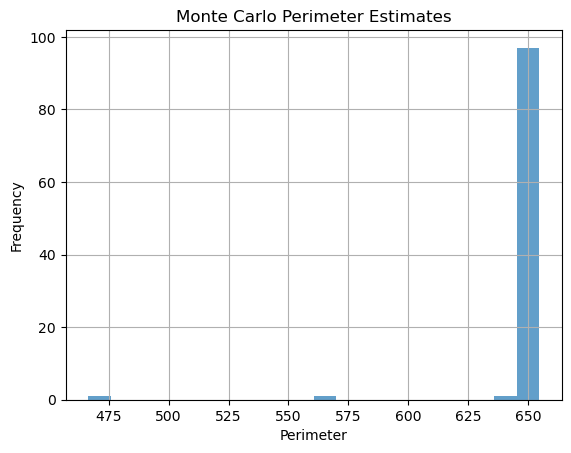

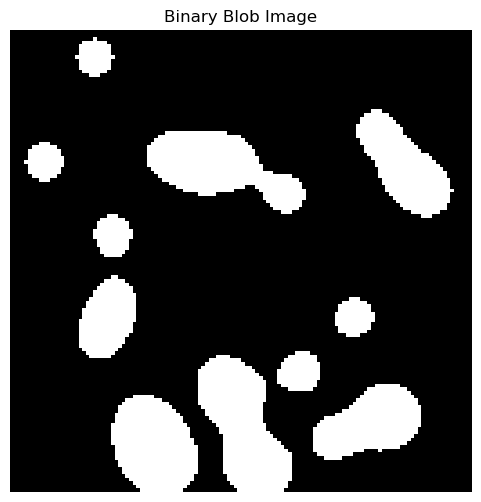

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import perimeter_crofton
from scipy.ndimage import shift
from skimage.util import random_noise

def monte_carlo_perimeter_uncertainty(image, n_iter=100, perturb='shift+noise', directions=8):
    """
    Estimate perimeter uncertainty via Monte Carlo simulation.

    Parameters:
        image (2D array): Binary image.
        n_iter (int): Number of perturbation samples.
        perturb (str): Type of perturbation: 'shift', 'noise', or 'shift+noise'.
        directions (int): Number of directions for Crofton perimeter (4 or 8).
        
    Returns:
        mean_perimeter (float)
        std_perimeter (float)
        all_perimeters (array)
    """
    perimeters = []
    for _ in range(n_iter):
        perturbed = image.copy()

        # Subpixel shift
        if 'shift' in perturb:
            dx, dy = np.random.uniform(-0.5, 0.5, size=2)
            perturbed = shift(perturbed, shift=(dy, dx), order=1, mode='nearest')

        # Add small Gaussian noise + threshold
        if 'noise' in perturb:
            noisy = random_noise(perturbed, mode='gaussian', var=0.001)
            perturbed = (noisy > 0.5).astype(float)

        # Compute perimeter
        p = perimeter_crofton(perturbed, directions=directions)
        perimeters.append(p)

    perimeters = np.array(perimeters)
    mean_p = np.mean(perimeters)
    std_p = np.std(perimeters)

    return mean_p, std_p, perimeters

# Example usage
if __name__ == "__main__":
    from skimage.data import binary_blobs
    image = binary_blobs(length=128, blob_size_fraction=0.2, volume_fraction=0.2)

    mean_p, std_p, perim_samples = monte_carlo_perimeter_uncertainty(image, n_iter=100, perturb='shift+noise', directions=8)

    print(f"Estimated perimeter: {mean_p:.2f} ± {std_p:.2f}")
    print(np.average(np.sqrt((perim_samples)))) # on average seems to underestimate it

    # Plot distribution
    plt.hist(perim_samples, bins=20, alpha=0.7)
    plt.title("Monte Carlo Perimeter Estimates")
    plt.xlabel("Perimeter")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap='gray')
    plt.title("Binary Blob Image")
    plt.axis('off')
    plt.show()

Estimated perimeter: 833.77 ± 47.61
Variance: 2266.73, Mean: 833.77, Var/Mean ratio: 2.719


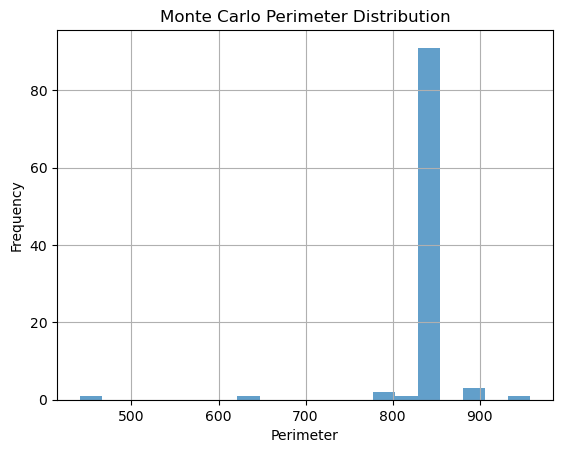

Estimated perimeter: 833.77 ± 47.61
[28.9764766  28.9764766  28.9764766  28.9764766  28.9764766  28.9764766
 28.9764766  28.91096605 28.91096605 28.9764766  28.9764766  28.9764766
 25.2997404  28.9764766  28.9764766  28.91096605 28.91096605 28.91096605
 28.9764766  28.91096605 28.9764766  28.9764766  28.97250694 28.9764766
 30.03070643 28.91096605 28.91096605 28.9764766  28.9764766  28.9764766
 28.9764766  28.91096605 28.91096605 28.9764766  28.91096605 28.9764766
 28.9764766  28.11153088 28.9764766  28.90135979 28.91096605 28.9764766
 28.91096605 29.83363887 28.91096605 28.91096605 28.91096605 28.91096605
 28.9764766  28.91096605 30.95588507 28.9764766  28.9764766  28.9764766
 28.9764766  28.91096605 28.91096605 28.9764766  28.91096605 28.9764766
 28.93016901 28.9764766  28.9764766  28.9764766  28.9764766  28.13776252
 28.91096605 28.91096605 28.91096605 28.9764766  28.91096605 28.9764766
 28.40030472 28.91096605 28.91096605 28.91096605 20.98584999 28.9764766
 28.9764766  28.91096605 

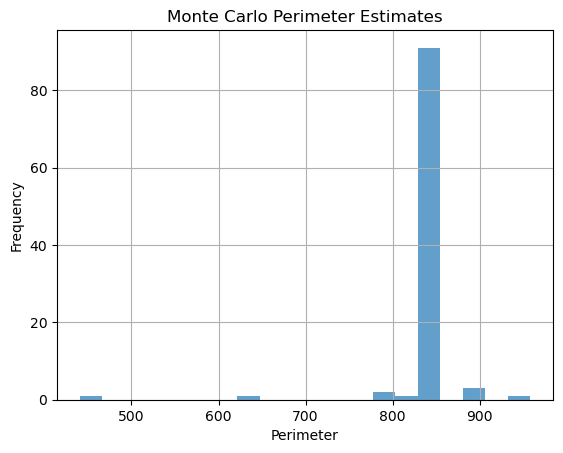

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import perimeter_crofton
from scipy.ndimage import shift
from skimage.util import random_noise

def monte_carlo_perimeter_uncertainty(image, n_iter=100, perturb='shift+noise', directions=8):
    perimeters = []
    for _ in range(n_iter):
        perturbed = image.copy()

        if 'shift' in perturb:
            dx, dy = np.random.uniform(-0.5, 0.5, size=2)
            perturbed = shift(perturbed, shift=(dy, dx), order=1, mode='nearest')

        if 'noise' in perturb:
            noisy = random_noise(perturbed, mode='gaussian', var=0.001)
            perturbed = (noisy > 0.5).astype(float)

        p = perimeter_crofton(perturbed, directions=directions)
        perimeters.append(p)

    perimeters = np.array(perimeters)
    mean_p = np.mean(perimeters)
    var_p = np.var(perimeters)
    std_p = np.std(perimeters)

    print(f"Estimated perimeter: {mean_p:.2f} ± {std_p:.2f}")
    print(f"Variance: {var_p:.2f}, Mean: {mean_p:.2f}, Var/Mean ratio: {var_p/mean_p:.3f}")

    # Optional: plot histogram
    plt.hist(perimeters, bins=20, alpha=0.7)
    plt.title("Monte Carlo Perimeter Distribution")
    plt.xlabel("Perimeter")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    return mean_p, std_p, perimeters

# Example usage
if __name__ == "__main__":
    from skimage.data import binary_blobs
    image = binary_blobs(length=128, blob_size_fraction=0.2, volume_fraction=0.3)

    mean_p, std_p, perim_samples = monte_carlo_perimeter_uncertainty(image, n_iter=100, perturb='shift+noise', directions=8)

    print(f"Estimated perimeter: {mean_p:.2f} ± {std_p:.2f}")
    print(np.sqrt((perim_samples)))

    # Plot distribution
    plt.hist(perim_samples, bins=20, alpha=0.7)
    plt.title("Monte Carlo Perimeter Estimates")
    plt.xlabel("Perimeter")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()